<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/17_KNN_Distance_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbours — Is This Biopsy Cancer?
**Problem Statement:** a pathology lab gets a new biopsy. KNN answers the way an experienced doctor does: *find the most similar past biopsies and see what they turned out to be.*

**About the data:** 569 real biopsies. A thin needle takes a few cells from the lump, a microscope photographs them, and software measures the **cell nuclei** (the dark centre of each cell). Cancer cells tend to have **bigger, rougher, more irregular** nuclei.

| Feature | What it measures |
|---|---|
| `radius` | average distance from the centre to the edge of the nucleus |
| `texture` | how uneven the grey shading inside the nucleus is |
| `perimeter` | length of the nucleus's outline |
| `area` | size of the nucleus (in pixels², values in the hundreds) |
| `smoothness` | how smooth the outline is (small bumps) |
| `compactness` | how far the shape is from a perfect circle |
| `concavity` | how deep the dents in the outline are |
| `concave_points` | how many dents the outline has |
| `symmetry` | how lopsided the nucleus is |
| `fractal_dimension` | how jagged / "coastline-like" the outline is |
| **`malignant`** | **target: 1 = cancer, 0 = benign** |

## 0. The Problem

In [ ]:
import numpy as np

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

!gdown 1VbUCO6Zc7H1_jRCRHgTVG8Rebe4EfQUD

biopsies = pd.read_csv("breast_cancer.csv")

Downloading...
From: https://drive.google.com/uc?id=1VbUCO6Zc7H1_jRCRHgTVG8Rebe4EfQUD
To: /content/breast_cancer.csv
100% 40.4k/40.4k [00:00<00:00, 22.3MB/s]


In [ ]:
print("biopsies:", len(biopsies))
biopsies.head()

biopsies: 569


,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,1


In [ ]:
biopsies.shape

(569, 11)

In [ ]:
biopsies['malignant'].value_counts()

,count
malignant,
0,357
1,212


In [ ]:
X = biopsies.drop(columns="malignant")
y = biopsies["malignant"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.shape, X_test.shape

((455, 10), (114, 10))

## 1. Distance: How Far Apart Are Two Biopsies?

In [ ]:
a = X.loc[0, ["radius", "texture"]].values
b = X.loc[1, ["radius", "texture"]].values
c = X.loc[2, ["radius", "texture"]].values

In [ ]:
print(a)
print(b)
print(c)

[17.99 10.38]
[20.57 17.77]
[19.69 21.25]


In [ ]:
e_ab = np.sqrt(((a - b) ** 2).sum())
e_ac = np.sqrt(((a - c) ** 2).sum())

print(e_ab)
print(e_ac)

7.827419753660845
11.002131611646899


In [ ]:
e_bc = np.sqrt(((b - c) ** 2).sum())
print(e_bc)

3.589540360547573


In [ ]:
m_ab = np.abs((a - b)).sum()
m_ac = np.abs((a - c)).sum()
print("Manhattan a&b:", round(m_ab, 2))
print("Manhattan a&c:", round(m_ac, 2))

Manhattan a&b: 9.97
Manhattan a&c: 12.57


In [ ]:
x_query = X_test.iloc[10].values
x_query

array([1.625e+01, 1.951e+01, 1.098e+02, 8.158e+02, 1.026e-01, 1.893e-01,
       2.236e-01, 9.194e-02, 2.151e-01, 6.578e-02])

In [ ]:
def distance(a, b):
    return np.sqrt(((a - b) ** 2).sum())

In [ ]:
distance(x_query, X_train.iloc[0])

np.float64(19.708754223593125)

In [ ]:
distance(x_query, X_train.iloc[1])

np.float64(353.15291767231577)

In [ ]:
distance(x_query, X_train.iloc[2])

np.float64(302.547459920383)

In [ ]:
distance(x_query, X_train.iloc[3])

np.float64(131.06821369079458)

In [ ]:
distance(x_query, X_train.iloc[5])

np.float64(1685.080914755557)

In [ ]:
# Step 1 : calculate all distances
all_distances = []
for i in range(len(X_train)):
    d = distance(x_query, X_train.iloc[i])
    all_distances.append(d)

In [ ]:
all_distances.sort()

In [ ]:
# Step 2 : select the top k nearest neighbours
most_similar_reports = np.argsort(all_distances)[:5]
most_similar_reports

array([ 61, 191, 233, 258,  96])

In [ ]:
X_train.iloc[most_similar_reports]

,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension
328,16.27,20.71,106.9,813.7,0.11690,0.13190,0.14780,0.08488,0.1948,0.06277
141,16.11,18.05,105.1,813.0,0.09721,0.11370,0.09447,0.05943,0.1861,0.06248
132,16.16,21.54,106.2,809.8,0.10080,0.12840,0.10430,0.05613,0.2160,0.05891
508,16.30,15.70,104.7,819.8,0.09427,0.06712,0.05526,0.04563,0.1711,0.05657
283,16.24,18.77,108.8,805.1,0.10660,0.18020,0.19480,0.09052,0.1876,0.06684


In [ ]:
x_query

array([1.625e+01, 1.951e+01, 1.098e+02, 8.158e+02, 1.026e-01, 1.893e-01,
       2.236e-01, 9.194e-02, 2.151e-01, 6.578e-02])

In [ ]:
# # Step 3 :  majority vote.
y_train[most_similar_reports]

,malignant
61,0
191,0
233,1
258,1
96,0


In [ ]:
y_test.iloc[10]

np.int64(1)

In [ ]:
# Practice 1: distance between biopsy 0 and biopsy 2 using radius and texture.
# Then add "area" to the list of columns and compute it again. What happens to the distance?

## 2. KNN: Find the Nearest, Take a Vote

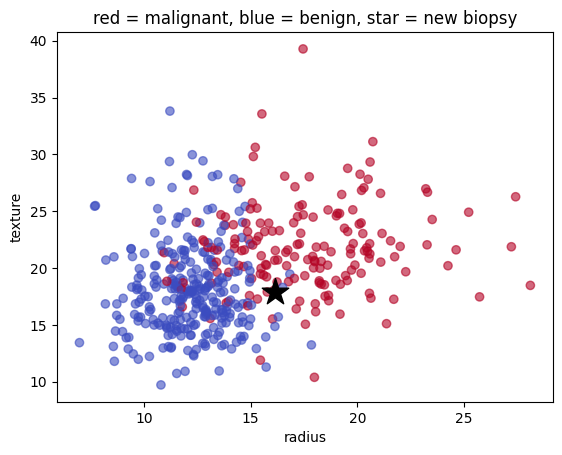

In [ ]:
new = X_test.iloc[23]      # a biopsy the model has never seen

plt.scatter(X_train["radius"], X_train["texture"], c=y_train, cmap="coolwarm", alpha=0.6)
plt.scatter(new["radius"], new["texture"], marker="*", s=400, color="black")
plt.xlabel("radius")
plt.ylabel("texture")
plt.title("red = malignant, blue = benign, star = new biopsy")
plt.show()

In [ ]:
distance = ((X_train - new) ** 2).sum(axis=1) ** 0.5     # Euclidean distance to all 455 training biopsies
nearest = distance.sort_values().head(5)

print("5 nearest distances:", nearest.round(1).tolist())
print("their diagnoses:    ", y_train[nearest.index].tolist())

5 nearest distances: [2.9, 4.6, 6.1, 6.7, 7.1]
their diagnoses:     [1, 1, 1, 1, 1]


In [ ]:
# nearest

In [ ]:
def report(model, X_test):     # accuracy + how many cancers the model called benign
    pred = model.predict(X_test)
    missed = ((pred == 0) & (y_test == 1)).sum()
    print("accuracy:", round(accuracy_score(y_test, pred), 3), "| cancers missed:", missed, "of", y_test.sum())

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

label = knn.predict(X_test.iloc[[23]])[0]

print("sklearn's vote for biopsy 23:", label)
print("actual diagnosis:            ", y_test.iloc[23])
report(knn, X_test)

sklearn's vote for biopsy 23: 1
actual diagnosis:             1
accuracy: 0.868 | cancers missed: 10 of 42


In [ ]:
y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.868421052631579

In [ ]:
from sklearn.metrics import recall_score

In [ ]:
recall_score(y_test, y_pred)

0.7619047619047619

In [ ]:
# Practice 2: repeat the by-hand vote for test biopsy 120 (new = X_test.loc[120]).
# Does your majority vote match knn.predict(X_test.loc[[120]])? Was it right?

## 3. The Scaling Trap

In [ ]:
X_train.describe().loc[["min", "mean", "max"]].round(3)

,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension
min,6.981,9.710,43.790,143.500,0.063,0.019,0.000,0.000,0.106,0.050
mean,14.166,19.418,92.216,659.578,0.096,0.104,0.089,0.049,0.181,0.063
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


In [ ]:
share = ((X_train - new) ** 2).sum()      # how much each feature adds to biopsy 7's distances
(share / share.sum()).round(3)

,0
radius,0.000
texture,0.000
perimeter,0.005
area,0.994
smoothness,0.000
compactness,0.000
concavity,0.000
concave_points,0.000
symmetry,0.000
fractal_dimension,0.000


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train) # learn mu and sig
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
report(knn_scaled, X_test_scaled)

accuracy: 0.947 | cancers missed: 3 of 42


In [ ]:
y_test.value_counts()

,count
malignant,
0,72
1,42


In [ ]:
new_scaled = scaler.transform(X_test.loc[[7]])

print("biopsy 7, unscaled [benign, malignant]:", knn.predict_proba(X_test.loc[[7]])[0])
print("biopsy 7, scaled   [benign, malignant]:", knn_scaled.predict_proba(new_scaled)[0])

biopsy 7, unscaled [benign, malignant]: [0.8 0.2]
biopsy 7, scaled   [benign, malignant]: [0. 1.]


In [ ]:
# Practice 3: fit an UNSCALED KNN (K=5) on the area column alone: X_train[["area"]], X_test[["area"]].
# Compare it with the unscaled 10-feature model. What does that tell you?

## 4. Choosing K

In [ ]:
train_perf = []
test_perf  = []

for k in [1, 3, 5, 9, 15, 25, 51, 101, 201]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    train_perf.append(train_acc)
    test_perf.append(test_acc)
    print("K =", k, "| train", round(train_acc, 3), "| test", round(test_acc, 3))

K = 1 | train 1.0 | test 0.939
K = 3 | train 0.965 | test 0.921
K = 5 | train 0.952 | test 0.947
K = 9 | train 0.947 | test 0.956
K = 15 | train 0.941 | test 0.965
K = 25 | train 0.947 | test 0.947
K = 51 | train 0.945 | test 0.93
K = 101 | train 0.93 | test 0.904
K = 201 | train 0.881 | test 0.868


In [ ]:
# Q1-Why is training accuracy always 100 % at K = 1?
# Q2-K goes from 15 to 201 and test accuracy falls. Overfitting or underfitting?
# Q3-Why prefer K = 5 over K = 4 here?
# Q4- .fit() in knn what happens?
# Q5-Give one reason not to use KNN on 10 million customers/biospy/data-points

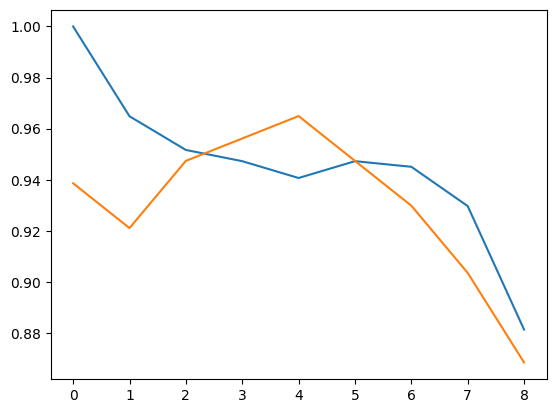

In [ ]:
plt.plot(train_perf)
plt.plot(test_perf)
plt.show()

In [ ]:
# Practice 4: try K = 455 (every training biopsy votes). What is the test accuracy?
# What does the model predict for every biopsy, and why?


# 5. Plot Boundaries

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay

def plot_boundary(k):     # KNN on 2 features only, so we can draw it
    cols = ["radius", "texture"]
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train[cols], y_train)
    DecisionBoundaryDisplay.from_estimator(model, X_train[cols], response_method="predict",
                                             cmap="coolwarm", alpha=0.3)
    plt.scatter(X_train["radius"], X_train["texture"], c=y_train, cmap="coolwarm", s=15)
    plt.title(f"K = {k}   (red area = predicted malignant)")
    plt.show()

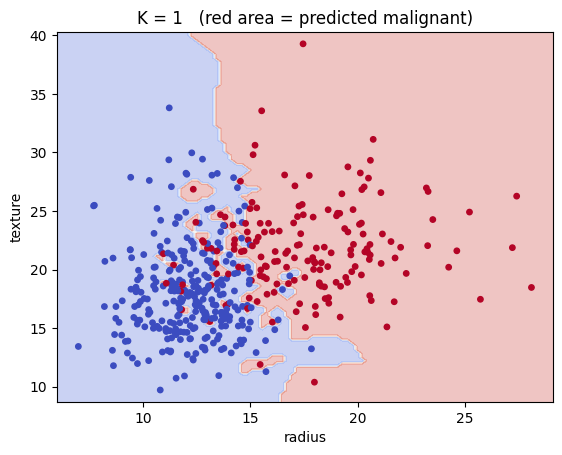

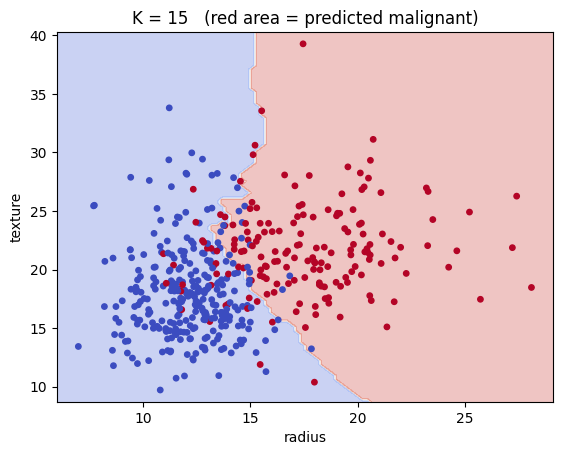

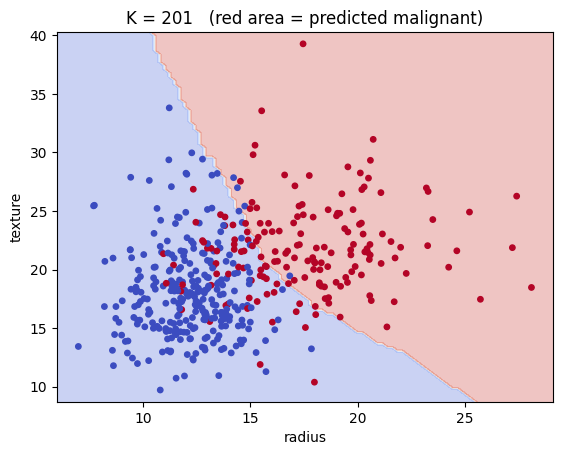

In [ ]:
plot_boundary(1)
plot_boundary(15)
plot_boundary(201)

In [ ]:
# Practice 5: call plot_boundary with K = 3, 51 and 455. Where does the boundary go at K = 455?

## Interview prep quesitons:


1. How does KNN make a prediction?
2. Why is KNN called a lazy learner? What is the consequence?
3. Euclidean vs Manhattan distance?
4. Why does KNN need feature scaling but a decision tree doesn't?
5. How does K affect bias and variance?
6. How do you choose K?
7. What is the curse of dimensionality, and why does it hurt KNN?
8. Can KNN do regression?
9. What does KNN's predict_proba return?
10. What is weights="distance" in KNeighborsClassifier?
11. Where is KNN used in industry?
12. How does KNN handle categorical features?

In [ ]:
# modelling -> xgboost ( ensemble model / decision tree )